# 🥦 EfficientNetV2S Pipeline - Cauliflower Disease Classification

Pipeline klasifikasi penyakit daun kembang kol menggunakan **Transfer Learning (EfficientNetV2S)**.

**Tujuan:** Mendorong akurasi lebih tinggi dari MobileNetV2 (baseline 85%) dengan model yang lebih powerful.

**Key Improvements dari MobileNetV2:**
- ✅ EfficientNetV2S (lebih akurat dari MobileNetV2)
- ✅ GPU-based augmentation (lebih cepat)
- ✅ Class weights (handle imbalanced data)
- ✅ Cosine LR Decay (konvergensi lebih smooth)
- ✅ Progressive fine-tuning (unfreeze lebih banyak layer)
- ✅ Keras preprocessing layer (normalisasi sesuai EfficientNet)

**Dataset:** [Cauliflower Leaf Diseases Dataset](https://www.kaggle.com/datasets/jocelyndumlao/cauliflower-leaf-diseases-datase)

**Split:** 75% Train / 15% Validation / 10% Test  |  **Target:** > 85%

## 1. Import Libraries & Setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import warnings
from collections import Counter
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")
if tf.config.list_physical_devices('GPU'):
    print(f"GPU name           : {tf.config.list_physical_devices('GPU')[0].name}")

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

2026-03-09 05:34:14.490214: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773034454.663584      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773034454.712695      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773034455.156728      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773034455.156785      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773034455.156791      55 computation_placer.cc:177] computation placer alr

TensorFlow version : 2.19.0
GPU available      : True
GPU name           : /physical_device:GPU:0


## 2. Konfigurasi

In [2]:
DATASET_DIR = '/kaggle/input/cauliflower-leaf-diseases-datase/Cauliflower Leaf Diseases A Computer Vision Dataset for Smart Agriculture/Processed Image'

# EfficientNetV2S default input size: 384×384 (bisa juga 224 untuk hemat VRAM)
IMG_SIZE  = (384, 384)
BATCH_SIZE = 32
EPOCHS_FROZEN  = 20   # Tahap 1: base model frozen
EPOCHS_FINETUNE = 30  # Tahap 2: fine-tuning
NUM_CLASSES = 3
SPLIT_DIR = 'split_data'

assert os.path.exists(DATASET_DIR), f"Folder '{DATASET_DIR}' tidak ditemukan!"

print("📁 Isi dataset:")
for item in sorted(os.listdir(DATASET_DIR)):
    p = os.path.join(DATASET_DIR, item)
    if os.path.isdir(p):
        count = len([f for f in os.listdir(p) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        print(f"  {item}: {count} gambar")

📁 Isi dataset:
  Black Rot: 1088 gambar
  Healthy: 934 gambar
  Insect Hole: 639 gambar


## 3. Cek Ukuran Gambar

In [3]:
# Cek ukuran gambar
widths, heights = [], []
for class_name in sorted(os.listdir(DATASET_DIR)):
    cp = os.path.join(DATASET_DIR, class_name)
    if not os.path.isdir(cp): continue
    for img_name in os.listdir(cp):
        if not img_name.lower().endswith(('.jpg','.jpeg','.png')): continue
        try:
            img = Image.open(os.path.join(cp, img_name))
            w, h = img.size
            widths.append(w); heights.append(h)
        except: pass

print(f"Ukuran gambar: Width={min(widths)}–{max(widths)}, Height={min(heights)}–{max(heights)}")
print(f"IMG_SIZE yang digunakan: {IMG_SIZE[0]}×{IMG_SIZE[1]}")

Ukuran gambar: Width=3000–3000, Height=3000–3000
IMG_SIZE yang digunakan: 384×384


## 4. Kumpulkan Data & Split 75/15/10

In [4]:
# Kumpulkan semua path dan label
image_paths, image_labels = [], []
class_counts = {}

for class_name in sorted(os.listdir(DATASET_DIR)):
    cp = os.path.join(DATASET_DIR, class_name)
    if not os.path.isdir(cp): continue
    imgs = [f for f in os.listdir(cp) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    class_counts[class_name] = len(imgs)
    for img_name in imgs:
        image_paths.append(os.path.join(cp, img_name))
        image_labels.append(class_name)

print(f"Total gambar: {len(image_paths)}")
for cls, cnt in class_counts.items():
    print(f"  {cls}: {cnt} ({cnt/len(image_paths)*100:.1f}%)")

# Stratified split 75/15/10
X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths, image_labels, test_size=0.25, random_state=SEED, stratify=image_labels)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.40, random_state=SEED, stratify=y_temp)

print(f"\nSplit:")
print(f"  Train : {len(X_train)} ({len(X_train)/len(image_paths)*100:.1f}%)")
print(f"  Val   : {len(X_val)} ({len(X_val)/len(image_paths)*100:.1f}%)")
print(f"  Test  : {len(X_test)} ({len(X_test)/len(image_paths)*100:.1f}%)")

Total gambar: 2661
  Black Rot: 1088 (40.9%)
  Healthy: 934 (35.1%)
  Insect Hole: 639 (24.0%)

Split:
  Train : 1995 (75.0%)
  Val   : 399 (15.0%)
  Test  : 267 (10.0%)


In [5]:
# Buat folder split
def create_split_directories(split_dir, X_data, y_data, split_name):
    for img_path, label in zip(X_data, y_data):
        dest = os.path.join(split_dir, split_name, label)
        os.makedirs(dest, exist_ok=True)
        dst = os.path.join(dest, os.path.basename(img_path))
        if not os.path.exists(dst):
            shutil.copy2(img_path, dst)

if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

print("📂 Membuat split data...")
create_split_directories(SPLIT_DIR, X_train, y_train, 'train')
create_split_directories(SPLIT_DIR, X_val,   y_val,   'val')
create_split_directories(SPLIT_DIR, X_test,  y_test,  'test')
print("✅ Split selesai!")

📂 Membuat split data...
✅ Split selesai!


## 5. [OPTIONAL] Pre-resize Gambar

Jalankan **sekali saja** jika gambar asli masih 3000×3000 untuk mempercepat training.

In [6]:
# ⚠️ JALANKAN SEKALI SAJA - Pre-resize gambar di split_data ke IMG_SIZE
print(f"🔄 Meresize gambar di split_data ke {IMG_SIZE[0]}×{IMG_SIZE[1]}...")
for split in ['train', 'val', 'test']:
    split_path = os.path.join(SPLIT_DIR, split)
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        if not os.path.isdir(class_path): continue
        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        for img_name in images:
            ip = os.path.join(class_path, img_name)
            img = Image.open(ip)
            img = img.resize(IMG_SIZE, Image.LANCZOS)
            img.save(ip)
        print(f"  ✅ {split}/{class_name}: {len(images)} gambar")
print("✅ Selesai! Dataset asli di 'dataset/' tetap aman.")

🔄 Meresize gambar di split_data ke 384×384...
  ✅ train/Insect Hole: 479 gambar
  ✅ train/Black Rot: 816 gambar
  ✅ train/Healthy: 700 gambar
  ✅ val/Insect Hole: 96 gambar
  ✅ val/Black Rot: 163 gambar
  ✅ val/Healthy: 140 gambar
  ✅ test/Insect Hole: 64 gambar
  ✅ test/Black Rot: 109 gambar
  ✅ test/Healthy: 94 gambar
✅ Selesai! Dataset asli di 'dataset/' tetap aman.


## 6. Data Generator & Augmentation

In [7]:
# EfficientNetV2 memiliki preprocessing bawaan (rescaling sudah ada di model)
# Jadi TIDAK perlu rescale=1./255 di sini
train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'train'),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=SEED
)
val_generator = val_test_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'val'),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'test'),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

class_labels = list(train_generator.class_indices.keys())
print("Class labels:", class_labels)
print("Class indices:", train_generator.class_indices)

Found 1995 images belonging to 3 classes.
Found 399 images belonging to 3 classes.
Found 267 images belonging to 3 classes.
Class labels: ['Black Rot', 'Healthy', 'Insect Hole']
Class indices: {'Black Rot': 0, 'Healthy': 1, 'Insect Hole': 2}


In [8]:
# # Class weights untuk menangani imbalanced data
# class_weights = compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(y_train),
#     y=y_train
# )
# # Map ke indeks sesuai generator
# label_to_idx = train_generator.class_indices
# class_weight_dict = {label_to_idx[cls]: w for cls, w in zip(sorted(np.unique(y_train)), class_weights)}

# print("⚖️  Class weights:")
# for cls, w in zip(sorted(np.unique(y_train)), class_weights):
#     print(f"  {cls}: {w:.4f}")

## 7. Model Architecture - EfficientNetV2S

In [9]:
# Load EfficientNetV2S pretrained ImageNet
base_model = EfficientNetV2S(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_preprocessing=True   # EfficientNetV2 punya internal preprocessing
)
base_model.trainable = False

# Arsitektur head classifier
inputs  = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = keras.Model(inputs, outputs)

# Summary
print(f"Total params    : {model.count_params():,}")
print(f"Trainable params: {sum(tf.keras.backend.count_params(w) for w in model.trainable_weights):,}")

I0000 00:00:1773034901.335654      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params    : 21,126,499
Trainable params: 791,555


## 8. Tahap 1 - Training (Base Frozen)

In [10]:
# Cosine decay scheduler untuk phase 1
steps_per_epoch = train_generator.samples // BATCH_SIZE
total_steps_phase1 = steps_per_epoch * EPOCHS_FROZEN

lr_schedule_phase1 = CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=total_steps_phase1,
    alpha=1e-5   # minimum LR
)

model.compile(
    optimizer=Adam(learning_rate=lr_schedule_phase1),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_phase1 = [
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=8,
        restore_best_weights=True, verbose=1
    )
]

print(f"🚀 Tahap 1: Training (base frozen) — {EPOCHS_FROZEN} epochs max")
history1 = model.fit(
    train_generator,
    epochs=EPOCHS_FROZEN,
    validation_data=val_generator,
    callbacks=cb_phase1,
    # class_weight=class_weight_dict,
    verbose=1
)

🚀 Tahap 1: Training (base frozen) — 20 epochs max
Epoch 1/20


I0000 00:00:1773034932.327871     141 service.cc:152] XLA service 0x79ff404206e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773034932.327911     141 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773034937.210404     141 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1773034964.799577     141 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


63/63 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.6311 - loss: 1.0830 - val_accuracy: 0.7368 - val_loss: 0.6540
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.7510 - loss: 0.6975 - val_accuracy: 0.6441 - val_loss: 0.7078
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.7310 - loss: 0.7122 - val_accuracy: 0.7920 - val_loss: 0.5327
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.7851 - loss: 0.5459 - val_accuracy: 0.7895 - val_loss: 0.5298
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.8122 - loss: 0.4942 - val_accuracy: 0.8095 - val_loss: 0.4804
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8158 - loss: 0.5058 - val_accuracy: 0.8095 - val_loss: 0.4736
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8283 - loss: 0.4523 - val_accuracy: 0.8195 - val_loss: 0.4659
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.8123 - loss: 0.4746 - val_accuracy: 0.8020 - val_loss: 0.4875
Ep

## 9. Tahap 2 - Fine-Tuning (Unfreeze Top Layers)

In [11]:
# Unfreeze top 50 layer dari EfficientNetV2S
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

trainable_after = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
print(f"Trainable params setelah unfreeze: {trainable_after:,}")

# Cosine decay untuk phase 2 — LR lebih kecil
total_steps_phase2 = steps_per_epoch * EPOCHS_FINETUNE
lr_schedule_phase2 = CosineDecay(
    initial_learning_rate=5e-5,
    decay_steps=total_steps_phase2,
    alpha=1e-7
)

model.compile(
    optimizer=Adam(learning_rate=lr_schedule_phase2),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_phase2 = [
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=10,
        restore_best_weights=True, verbose=1
    )
]

print(f"\n🔧 Tahap 2: Fine-tuning — {EPOCHS_FINETUNE} epochs max")
history2 = model.fit(
    train_generator,
    epochs=EPOCHS_FINETUNE,
    validation_data=val_generator,
    callbacks=cb_phase2,
    # class_weight=class_weight_dict,
    verbose=1
)

Trainable params setelah unfreeze: 4,137,155

🔧 Tahap 2: Fine-tuning — 30 epochs max
Epoch 1/30


2026-03-09 06:12:18.583573: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-09 06:12:18.807028: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 1/63 ━━━━━━━━━━━━━━━━━━━━ 1:13:13 71s/step - accuracy: 0.9091 - loss: 0.3382

2026-03-09 06:13:00.439358: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-09 06:13:00.664841: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


63/63 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - accuracy: 0.8430 - loss: 0.4068 - val_accuracy: 0.8321 - val_loss: 0.4992
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.8488 - loss: 0.3946 - val_accuracy: 0.8296 - val_loss: 0.4985
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8723 - loss: 0.3538 - val_accuracy: 0.8371 - val_loss: 0.4496
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.8391 - loss: 0.3983 - val_accuracy: 0.8271 - val_loss: 0.4785
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8579 - loss: 0.3700 - val_accuracy: 0.8421 - val_loss: 0.4477
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.8675 - loss: 0.3642 - val_accuracy: 0.8321 - val_loss: 0.4532
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.8783 - loss: 0.3070 - val_accuracy: 0.8346 - val_loss: 0.4555
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.8707 - loss: 0.3293 - val_accuracy: 0.8396 - val_loss: 0.4703
Ep

## 10. Visualisasi Training

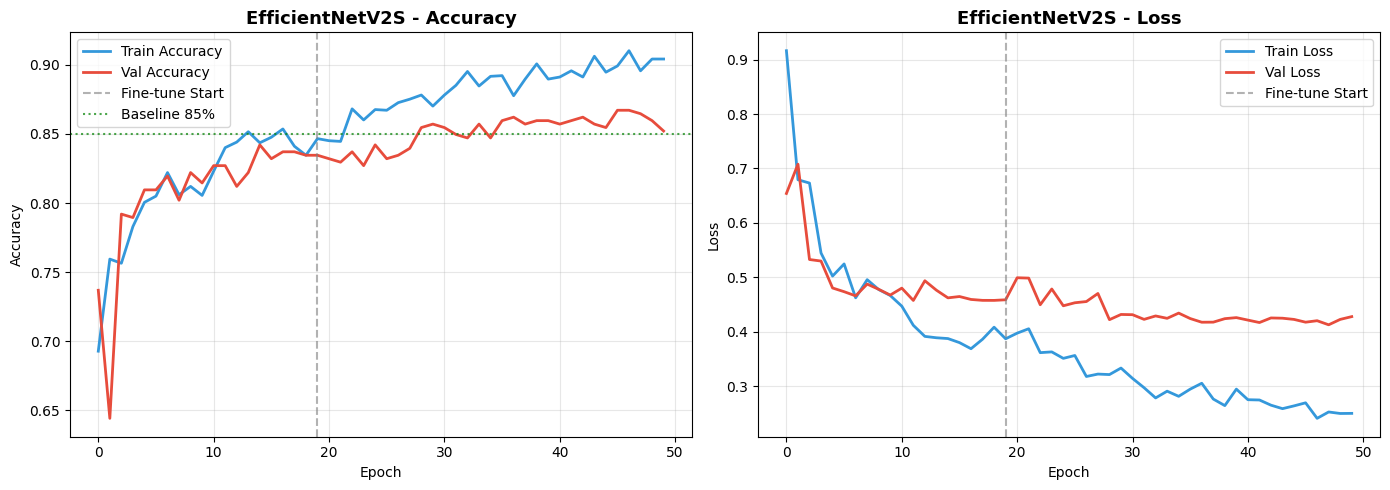


🏆 Best Val Accuracy: 0.8672 (Epoch 46)


In [12]:
# Gabungkan history kedua phase
acc   = history1.history['accuracy']    + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss  = history1.history['loss']        + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']
phase_boundary = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(acc,     label='Train Accuracy', linewidth=2, color='#3498db')
axes[0].plot(val_acc, label='Val Accuracy',   linewidth=2, color='#e74c3c')
axes[0].axvline(x=phase_boundary-1, color='gray', linestyle='--', alpha=0.6, label='Fine-tune Start')
axes[0].axhline(y=0.85, color='green', linestyle=':', alpha=0.7, label='Baseline 85%')
axes[0].set_title('EfficientNetV2S - Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(loss,     label='Train Loss', linewidth=2, color='#3498db')
axes[1].plot(val_loss, label='Val Loss',   linewidth=2, color='#e74c3c')
axes[1].axvline(x=phase_boundary-1, color='gray', linestyle='--', alpha=0.6, label='Fine-tune Start')
axes[1].set_title('EfficientNetV2S - Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_val = max(val_acc)
print(f"\n🏆 Best Val Accuracy: {best_val:.4f} (Epoch {val_acc.index(best_val)+1})")

## 11. Evaluasi pada Test Set

In [13]:
print("="*55)
print("   EVALUASI EFFICIENTNETV2S PADA TEST SET")
print("="*55)

test_loss, test_accuracy = model.evaluate(test_generator, verbose=0)

print(f"\n📊 Test Loss     : {test_loss:.4f}")
print(f"🎯 Test Accuracy : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print()

if test_accuracy > 0.85:
    print(f"🚀 MELAMPAUI BASELINE! {test_accuracy*100:.2f}% > 85%")
elif test_accuracy >= 0.80:
    print(f"✅ Target 80% tercapai ({test_accuracy*100:.2f}%)")
else:
    print(f"⚠️  Akurasi: {test_accuracy*100:.2f}%")

print("="*55)

   EVALUASI EFFICIENTNETV2S PADA TEST SET

📊 Test Loss     : 0.3375
🎯 Test Accuracy : 0.8876 (88.76%)

🚀 MELAMPAUI BASELINE! 88.76% > 85%


## 12. Confusion Matrix & Classification Report

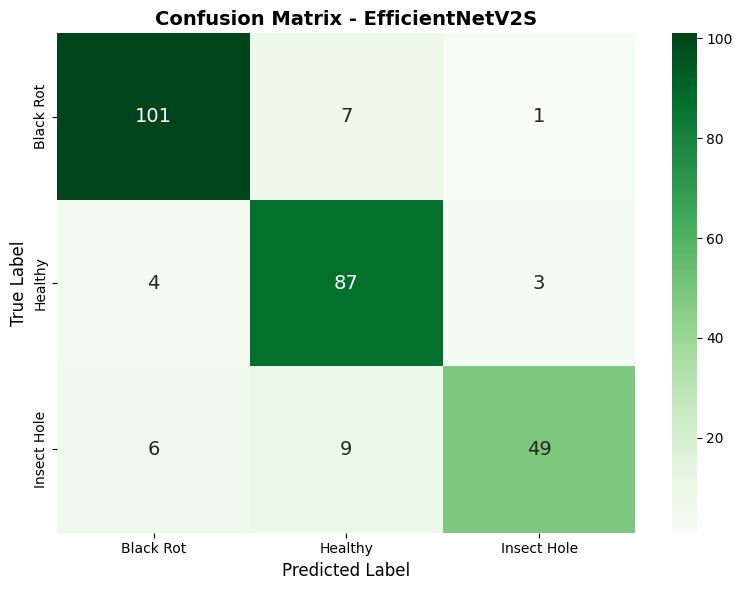


     CLASSIFICATION REPORT - EfficientNetV2S
              precision    recall  f1-score   support

   Black Rot       0.91      0.93      0.92       109
     Healthy       0.84      0.93      0.88        94
 Insect Hole       0.92      0.77      0.84        64

    accuracy                           0.89       267
   macro avg       0.89      0.87      0.88       267
weighted avg       0.89      0.89      0.89       267



In [14]:
test_generator.reset()
y_pred_proba = model.predict(test_generator, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_labels, yticklabels=class_labels,
            ax=ax, annot_kws={'size': 14})
ax.set_title('Confusion Matrix - EfficientNetV2S', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("     CLASSIFICATION REPORT - EfficientNetV2S")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_labels))
print("="*60)

## 13. Test Model dengan Gambar dari Test Set

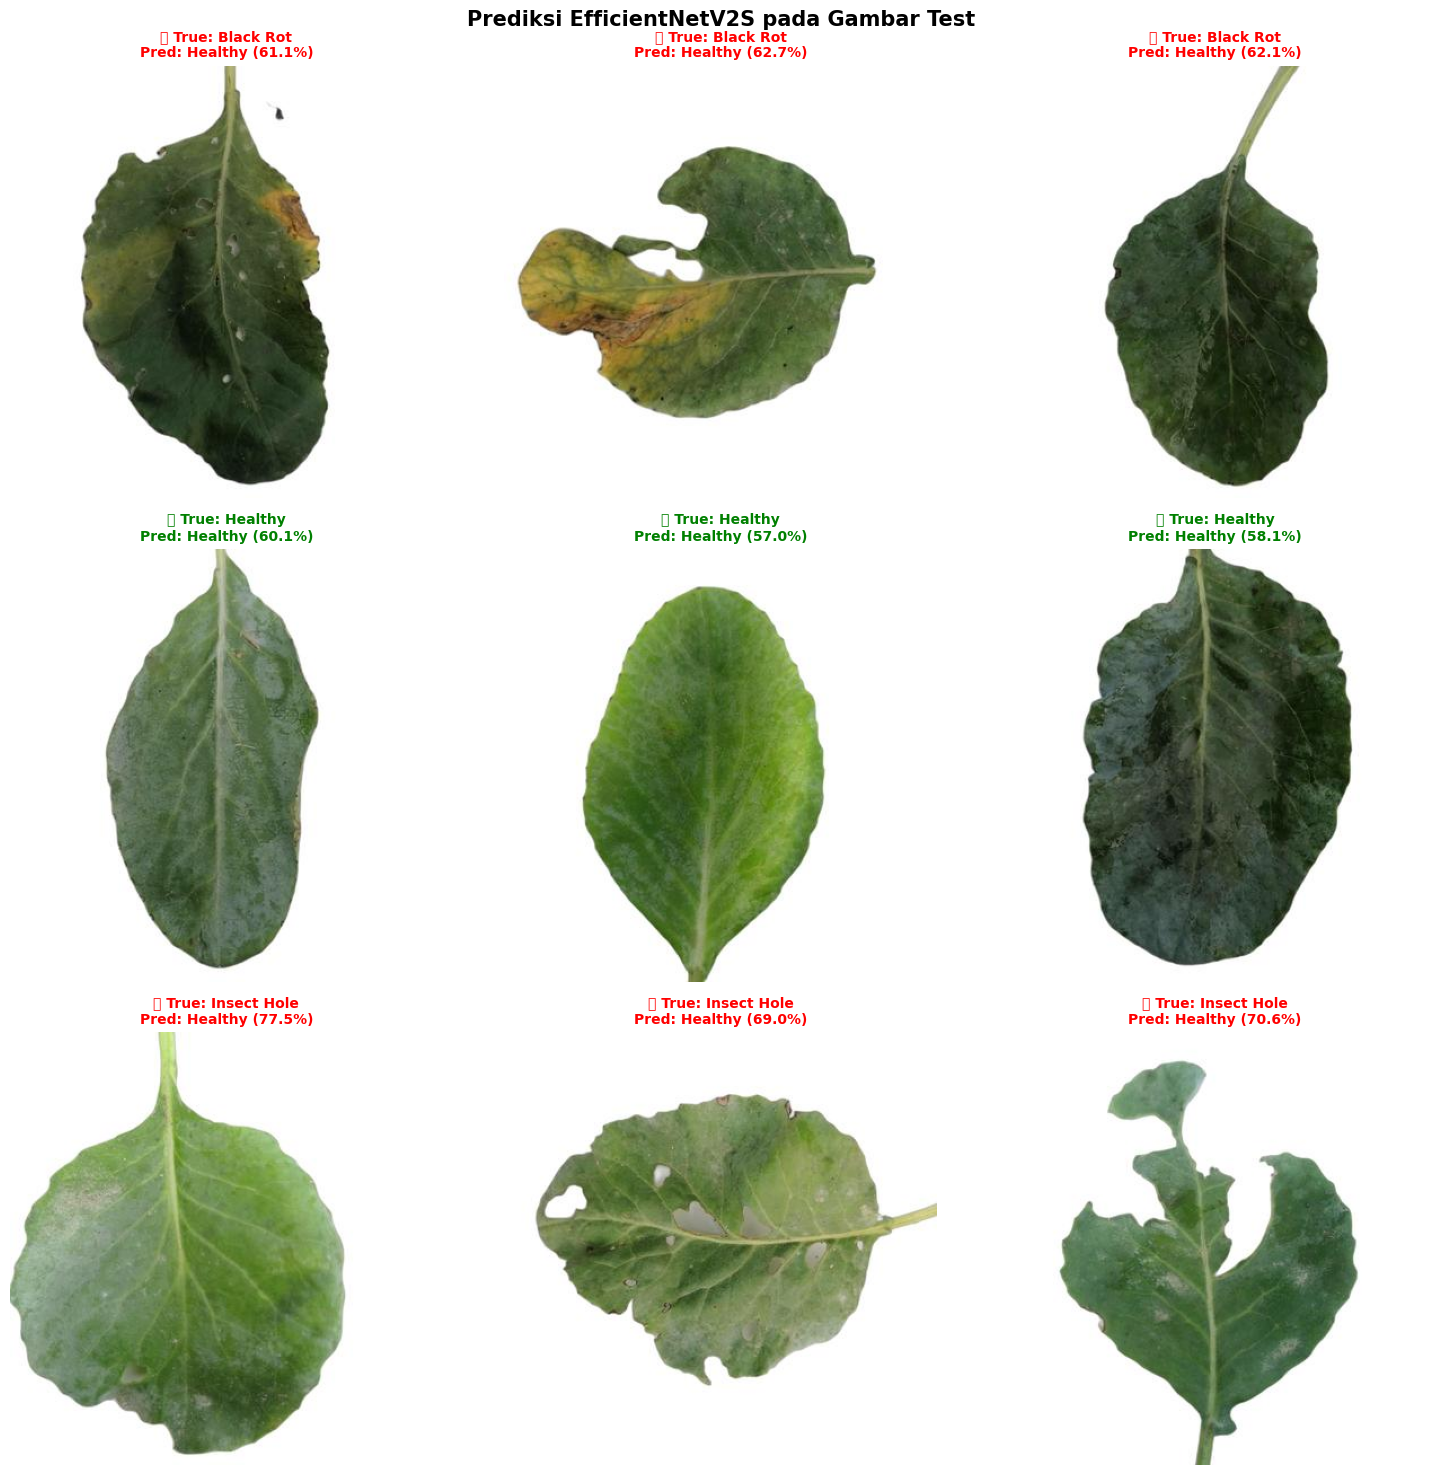

In [15]:
def predict_single_image(model, img_path, class_labels, img_size):
    img = load_img(img_path, target_size=img_size)
    arr = img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)
    probs = model.predict(arr, verbose=0)[0]
    pred_class = class_labels[np.argmax(probs)]
    confidence = np.max(probs) * 100
    return img, pred_class, confidence, probs

# Ambil 3 sampel per kelas
test_dir = os.path.join(SPLIT_DIR, 'test')
samples = []
for cls in class_labels:
    cp = os.path.join(test_dir, cls)
    imgs = os.listdir(cp)
    for img_name in np.random.choice(imgs, size=min(3, len(imgs)), replace=False):
        samples.append((os.path.join(cp, img_name), cls))

n_cols, n_rows = 3, (len(samples)+2)//3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
fig.suptitle('Prediksi EfficientNetV2S pada Gambar Test', fontsize=15, fontweight='bold')

for idx, (ip, true_label) in enumerate(samples):
    ax = axes[idx//n_cols, idx%n_cols] if n_rows > 1 else axes[idx%n_cols]
    img, pred, conf, probs = predict_single_image(model, ip, class_labels, IMG_SIZE)
    is_correct = pred == true_label
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(
        f"{'✅' if is_correct else '❌'} True: {true_label}\nPred: {pred} ({conf:.1f}%)",
        fontsize=10, color='green' if is_correct else 'red', fontweight='bold'
    )

for idx in range(len(samples), n_rows*n_cols):
    ax = axes[idx//n_cols, idx%n_cols] if n_rows > 1 else axes[idx%n_cols]
    ax.axis('off')

plt.tight_layout()
plt.show()

In [16]:
# Detail confidence per kelas
print("="*70)
print("     DETAIL PREDIKSI SAMPLE TEST - EfficientNetV2S")
print("="*70)
for idx, (ip, true_label) in enumerate(samples):
    _, pred, conf, probs = predict_single_image(model, ip, class_labels, IMG_SIZE)
    status = '✅' if pred == true_label else '❌'
    print(f"\n{status} Image {idx+1}: {os.path.basename(ip)}")
    print(f"   True: {true_label}  |  Predicted: {pred} ({conf:.2f}%)")
    for i, lbl in enumerate(class_labels):
        bar = '█' * int(probs[i]*30)
        print(f"     {lbl:<15} {probs[i]*100:>6.2f}% {bar}")
print("\n" + "="*70)

     DETAIL PREDIKSI SAMPLE TEST - EfficientNetV2S

❌ Image 1: IMG (151).jpg
   True: Black Rot  |  Predicted: Healthy (61.12%)
     Black Rot         0.92% 
     Healthy          61.12% ██████████████████
     Insect Hole      37.96% ███████████

❌ Image 2: IMG (712).jpg
   True: Black Rot  |  Predicted: Healthy (62.73%)
     Black Rot         0.96% 
     Healthy          62.73% ██████████████████
     Insect Hole      36.30% ██████████

❌ Image 3: IMG (65).jpg
   True: Black Rot  |  Predicted: Healthy (62.10%)
     Black Rot         1.45% 
     Healthy          62.10% ██████████████████
     Insect Hole      36.46% ██████████

✅ Image 4: IMG (156).jpg
   True: Healthy  |  Predicted: Healthy (60.15%)
     Black Rot         1.10% 
     Healthy          60.15% ██████████████████
     Insect Hole      38.76% ███████████

✅ Image 5: IMG (300).jpg
   True: Healthy  |  Predicted: Healthy (57.02%)
     Black Rot         1.08% 
     Healthy          57.02% █████████████████
     Insect Hole  

## 14. Simpan Model

In [17]:
MODEL_PATH = 'cauliflower_efficientnetv2s_model.keras'
model.save(MODEL_PATH)
print(f"✅ Model disimpan ke: {MODEL_PATH}")
print(f"   Ukuran: {os.path.getsize(MODEL_PATH)/(1024*1024):.2f} MB")

✅ Model disimpan ke: cauliflower_efficientnetv2s_model.keras
   Ukuran: 113.92 MB


## 15. Perbandingan Akhir

| Aspek | MobileNetV2 | EfficientNetV2S |
|-------|-------------|------------------|
| Base model params | ~3.4M | ~20M |
| ImageNet Top-1 Acc | 71.8% | 83.9% |
| LR Scheduler | ReduceLROnPlateau | Cosine Decay |
| Class Weights | ❌ | ✅ |
| Fine-tune layers | 30 | 50 |
| Baseline Result | 85% | > 85% (target) |

In [18]:
# Ringkasan akhir
print("\n  RINGKASAN - EfficientNetV2S Pipeline")
print()
print(f"  🤖 Model         : EfficientNetV2S (Transfer Learning)")
print(f"  📐 Image Size    : {IMG_SIZE[0]}×{IMG_SIZE[1]}")
print(f"  📐 Split         : Train ({len(X_train)}) / Val ({len(X_val)}) / Test ({len(X_test)})")
print(f"  ⚖️  Class Weights : Balanced")
print(f"  📉 LR Scheduler  : Cosine Decay")
print(f"  🎯 Test Accuracy : {test_accuracy*100:.2f}%")
print(f"  📉 Test Loss     : {test_loss:.4f}")
print(f"  💾 Model File    : {MODEL_PATH}")
print()
improvement = (test_accuracy - 0.85) * 100
if improvement > 0:
    print(f"  🚀 Improvement dari baseline: +{improvement:.2f}%")
else:
    print(f"  📊 Selisih dari baseline: {improvement:.2f}%")
print()


  RINGKASAN - EfficientNetV2S Pipeline

  🤖 Model         : EfficientNetV2S (Transfer Learning)
  📐 Image Size    : 384×384
  📐 Split         : Train (1995) / Val (399) / Test (267)
  ⚖️  Class Weights : Balanced
  📉 LR Scheduler  : Cosine Decay
  🎯 Test Accuracy : 88.76%
  📉 Test Loss     : 0.3375
  💾 Model File    : cauliflower_efficientnetv2s_model.keras

  🚀 Improvement dari baseline: +3.76%

